<h1 style="
color:#0096FF; background-color:white;
font-weight:bold; 
text-align:center;">
Population Group Wise Deposits Analysis
</h1>


#  <h1 style="color: skyblue;"> Overview
This project focuses on analyzing the *Population-group Wise Deposits dataset, which contains information about deposits and banking-related statistics across different states and districts. The dataset includes details such as **year, state name, district name, region, population group, number of SCB offices, number of accounts, and total amount deposited*.

#  <h1 style="color: skyblue;"> Objective of the Project
The main objective of this project is to:
- Load the dataset using Python (Pandas)
- Understand the structure of the dataset (rows, columns, data types)
- Perform data cleaning and preprocessing
- Handle missing values and duplicates
- Convert columns into correct data types
- Create meaningful derived columns for better analysis
- Prepare a clean dataset for visualization and insights

#  <h1 style="color: skyblue;"> Why This Project is Important
Banking deposit data helps in understanding how different population groups such as *Rural and Urban* contribute to the banking system. This analysis helps in identifying:
- Which states/districts have higher deposits
- Deposit trends across years
- Differences between rural and urban deposit patterns
- Relationship between number of accounts and total deposits

#  <h1 style="color: skyblue;">  Tools and Technologies Used
- *Python*
- *Pandas* (for data handling and cleaning)
- *NumPy* (for calculations)
- *VS Code / Jupyter Notebook* (for coding)

#  <h1 style="color: skyblue;">  Expected Outcome
At the end of this project, we will obtain:
- A fully cleaned dataset
- Correct data types for all columns
- No missing values and duplicates
- Additional derived columns such as deposit per account
- A dataset ready for further analysis and visualization

#    Load Dataset

In [96]:
import pandas as pd
import numpy as np


In [97]:
df= pd.read_csv("Population-group  Wise Deposits_Sample_Data 1.csv")

#   Initial Overview

In [98]:
# Overview
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())
df.info()
print(df.describe())

Rows: 500
Columns: 10
   Year (year) State Name (state_name)  State Code (state_code)  \
0         2020             Uttarakhand                        5   
1         2019                     Goa                       30   
2         2021               Telangana                       36   
3         2021              Tamil Nadu                       33   
4         2020               Karnataka                       29   

  District Name (district_name)  District Code (district_code)  \
0                       Chamoli                             47   
1                     South Goa                            552   
2                      Jagitial                            681   
3               Tiruchirappalli                            591   
4                Chikkamagaluru                            532   

   Region (region) Population Group (population_group)  \
0   Central Region                               Rural   
1   Western Region                               Rural   
2  S

# Data Cleaning

- Finding Duplicates & Remove 

In [99]:
# Missing values + duplicates
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Year (year)                                      0
State Name (state_name)                          0
State Code (state_code)                          0
District Name (district_name)                    0
District Code (district_code)                    0
Region (region)                                  0
Population Group (population_group)              0
Number of SCB Offices (no_of_offices)            0
Number of Accounts with SCBs (no_of_accounts)    0
Amount deposited (deposit_amount)                0
dtype: int64
Duplicate rows: 0


In [100]:
# Remove duplicates
df = df.drop_duplicates()

No duplicate values found

 - Clean Columns

In [101]:
# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r"\s*\(.*?\)", "", regex=True)
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

- Convert Numeric Columns

In [102]:
# Convert numeric columns
df["year"] = df["year"].astype(int)
df["state_code"] = df["state_code"].astype(int)
df["district_code"] = df["district_code"].astype(int)

In [103]:
df["number_of_scb_offices"] = pd.to_numeric(df["number_of_scb_offices"], errors="coerce")
df["number_of_accounts_with_scbs"] = pd.to_numeric(df["number_of_accounts_with_scbs"], errors="coerce")
df["amount_deposited"] = pd.to_numeric(df["amount_deposited"], errors="coerce")

In [104]:
# Fill missing values
df["number_of_scb_offices"] = df["number_of_scb_offices"].fillna(0)
df["number_of_accounts_with_scbs"] = df["number_of_accounts_with_scbs"].fillna(0)
df["amount_deposited"] = df["amount_deposited"].fillna(0)

df["state_name"] = df["state_name"].fillna("Unknown")
df["district_name"] = df["district_name"].fillna("Unknown")
df["region"] = df["region"].fillna("Unknown")
df["population_group"] = df["population_group"].fillna("Unknown")

 - Derive Columns

In [105]:
# Derived column
df["deposit_per_account"] = np.where(
    df["number_of_accounts_with_scbs"] == 0,
    0,
    df["amount_deposited"] / df["number_of_accounts_with_scbs"]
)

  - Remove Leading & Trailing Space in Data

In [106]:
#Remove Leading & Trailing Space in Data
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

- Convert Text to Proper Format

In [107]:
#Convert Text to Proper Format
df["state_name"] = df["state_name"].str.title()
df["population_group"] = df["population_group"].str.capitalize()

- Remove Negative Values

In [108]:
#Remove Negative Values
df = df[df["amount_deposited"] >= 0]
df = df[df["number_of_accounts_with_scbs"] >= 0]

  - Outlier Detection 

In [109]:
#Outlier Detection
Q1 = df["amount_deposited"].quantile(0.25)
Q3 = df["amount_deposited"].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df["amount_deposited"] >= Q1 - 1.5*IQR) &
        (df["amount_deposited"] <= Q3 + 1.5*IQR)
]

In [110]:
df.rename(columns={
    "number_of_scb_offices": "scb_offices",
    "number_of_accounts_with_scbs": "accounts",
    "amount_deposited": "total_deposit"
}, inplace=True)

In [111]:
print(df.tail())

     year     state_name  state_code district_name  district_code  \
495  2020  Uttar Pradesh           9        Deoria            137   
496  2020      Jharkhand          20         Godda            330   
497  2022        Gujarat          24     Ahmadabad            438   
498  2019         Odisha          21       Cuttack            350   
499  2019          Delhi           7    North West             82   

              region population_group  scb_offices  accounts  total_deposit  \
495   Central Region            Urban           40       739           3883   
496   Eastern Region            Rural            0         0              0   
497   Western Region       Semi-urban            0         0              0   
498   Eastern Region            Rural          179      2342           5822   
499  Northern Region       Semi-urban            9       204           1026   

     deposit_per_account  
495             5.254398  
496             0.000000  
497             0.000000  
49

In [112]:
# Save cleaned dataset
df.to_csv("cleaned_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


##  <h1 style="color: skyblue; font-size: 70px;"> Exploratory Data Analysis

- Distibution of Population Group

In [113]:
print(df["population_group"].value_counts())

population_group
Rural           194
Semi-urban      185
Urban            68
Metropolitan      5
Name: count, dtype: int64


In [114]:
print(df.columns)

Index(['year', 'state_name', 'state_code', 'district_name', 'district_code',
       'region', 'population_group', 'scb_offices', 'accounts',
       'total_deposit', 'deposit_per_account'],
      dtype='object')


- Deposit Summary

In [115]:
print(df["total_deposit"].describe())

count     452.000000
mean      964.475664
std      1367.148093
min         0.000000
25%         0.000000
50%         0.000000
75%      1774.500000
max      5885.000000
Name: total_deposit, dtype: float64


In [116]:
#univarites analysis

print(df["total_deposit"].mean())
print(df["total_deposit"].median())
print(df["total_deposit"].mode())

964.4756637168142
0.0
0    0
Name: total_deposit, dtype: int64


- Deposit By Region

In [117]:
#Deposit by region

print(df.groupby("region")["total_deposit"].sum().sort_values(ascending=False))

region
Central Region          122160
Northern Region         103935
Southern Region          91999
Eastern Region           61597
Western Region           40815
North Eastern Region     15437
Name: total_deposit, dtype: int64


In [118]:

#Deposit by year
 
print(df.groupby(["year"])["total_deposit"].sum())

year
2019     94001
2020     96617
2021    116467
2022    128858
Name: total_deposit, dtype: int64


- Deposit By Popoulation Group

- Top 10 Deposit By State

In [119]:
#Top 10 states by deposit

top_states = df.groupby("state_name")["total_deposit"].sum().sort_values(ascending=False).head(10)
print(top_states)

state_name
Uttar Pradesh        85739
Rajasthan            33762
Karnataka            26500
Bihar                26466
Tamil Nadu           26112
Telangana            25362
Gujarat              23541
Punjab               20009
Jammu And Kashmir    19792
Odisha               17941
Name: total_deposit, dtype: int64


- Top 10 Deposit By District

In [120]:
#Top 10 district by deposit

top_districts = df.groupby("district_name")["total_deposit"].sum().sort_values(ascending=False).head(10)
print(top_districts)

district_name
Udhampur        7546
Moga            7457
Ballari         7394
Rajnandgaon     7274
Chittorgarh     7147
Cuttack         7062
Unnao           7007
Erode           6976
Gonda           6936
Banas Kantha    6253
Name: total_deposit, dtype: int64


- Pivot Table

In [121]:
#Pivot table

pivot_table = pd.pivot_table(
    df,
    values="total_deposit",
    index="state_name",
    columns="year",
    aggfunc="sum"
)

print(pivot_table)

year                                             2019     2020     2021  \
state_name                                                                
Andhra Pradesh                                 9748.0   2976.0      0.0   
Arunachal Pradesh                                 NaN      0.0      0.0   
Assam                                          2312.0      0.0   4947.0   
Bihar                                          6994.0   8242.0   4486.0   
Chandigarh                                        NaN      NaN      NaN   
Chhattisgarh                                      0.0  10853.0   3665.0   
Delhi                                          1026.0      NaN      NaN   
Goa                                               0.0      NaN      NaN   
Gujarat                                        3985.0   2136.0   9942.0   
Haryana                                        7602.0   1034.0      0.0   
Himachal Pradesh                                  NaN      NaN   2278.0   
Jammu And Kashmir        

- Correlation

In [122]:
df.columns = df.columns.str.strip()

df["scb_offices"] = pd.to_numeric(df["scb_offices"], errors="coerce")
df["accounts"] = pd.to_numeric(df["accounts"], errors="coerce")
df["total_deposit"] = pd.to_numeric(df["total_deposit"], errors="coerce")

df["deposit_per_account"] = df["total_deposit"] / df["accounts"]
df["deposit_per_office"] = df["total_deposit"] / df["scb_offices"]

corr = df[[
    "scb_offices",
    "accounts",
    "total_deposit",
    "deposit_per_account",
    "deposit_per_office"
]].corr()

print(corr)

                     scb_offices  accounts  total_deposit  \
scb_offices             1.000000  0.940743       0.828922   
accounts                0.940743  1.000000       0.820942   
total_deposit           0.828922  0.820942       1.000000   
deposit_per_account    -0.235126 -0.327098       0.361984   
deposit_per_office     -0.295540 -0.226841       0.393784   

                     deposit_per_account  deposit_per_office  
scb_offices                    -0.235126           -0.295540  
accounts                       -0.327098           -0.226841  
total_deposit                   0.361984            0.393784  
deposit_per_account             1.000000            0.843708  
deposit_per_office              0.843708            1.000000  


#  <h1 style="color: skyblue;">Visualization

## 1.  Box  Plot - Deposit By Population Group

In [123]:
import matplotlib.pyplot as plt

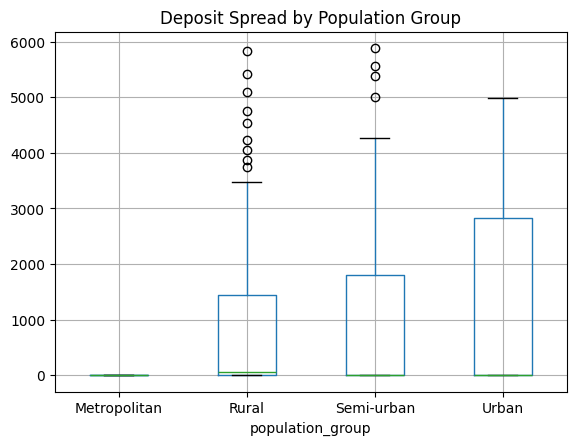

In [124]:
df.boxplot(column="total_deposit", by="population_group")
plt.title("Deposit Spread by Population Group")
plt.suptitle("")
plt.show()

##### Insight - Shows variation and outliers among groups

## 2. Pie Chart - Deposit Share By Region

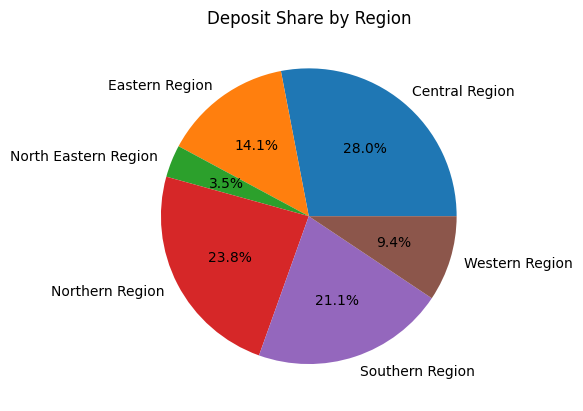

In [125]:
region_data = df.groupby("region")["total_deposit"].sum()
plt.pie(region_data, labels=region_data.index, autopct="%1.1f%%")
plt.title("Deposit Share by Region")
plt.show()

#### Insights - Shows percentage contributing of each region

## 3. Horizontal Bar - Top 10 States

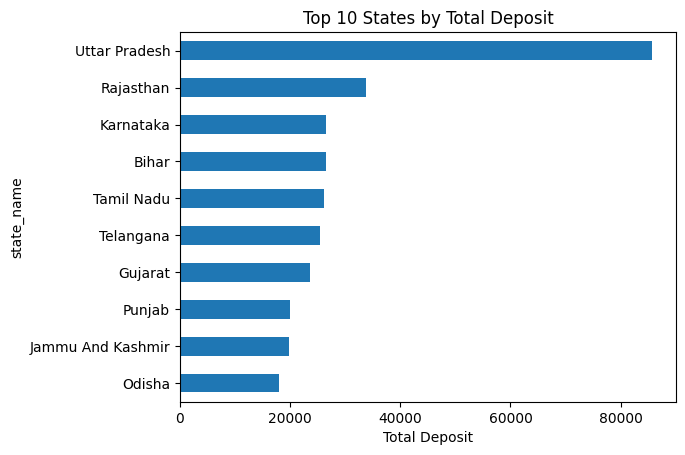

In [126]:
top_states = df.groupby("state_name")["total_deposit"].sum().sort_values().tail(10)

top_states.plot(kind="barh")
plt.title("Top 10 States by Total Deposit")
plt.xlabel("Total Deposit")
plt.show()

#### Insights - identifies highest contributing states

## 4. Line Chart - Year-Wise Total Deposit

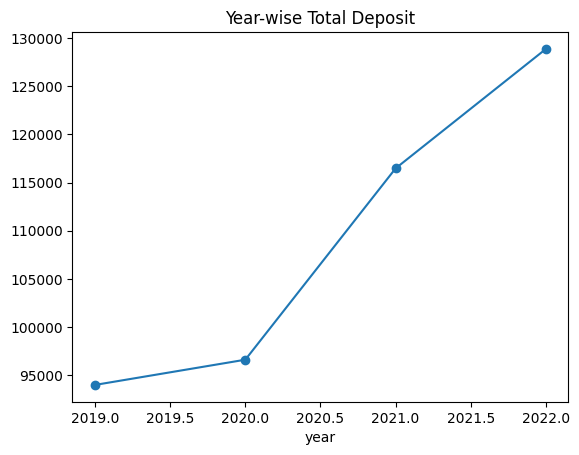

In [127]:
df.groupby("year")["total_deposit"].sum().plot(kind="line", marker="o")
plt.title("Year-wise Total Deposit")
plt.show()

####  Insight - Shows overall growth trend of deposits over time


## 5. Scatter Plot - Deposit VS Accounts

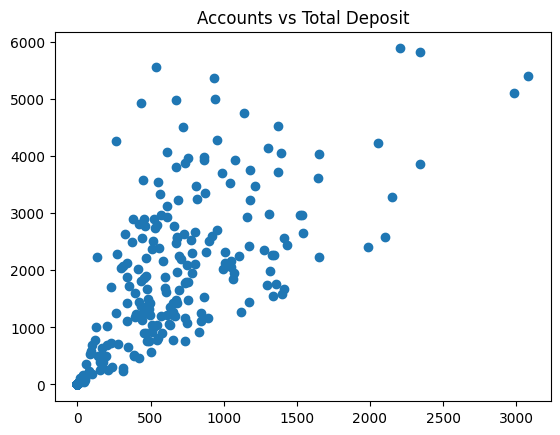

In [128]:
plt.scatter(df["accounts"], df["total_deposit"])
plt.title("Accounts vs Total Deposit")
plt.show()

#### Insight - Shows positive relationship between acounts and deposits

## 6. Bar Chart - Deposit By Population Group

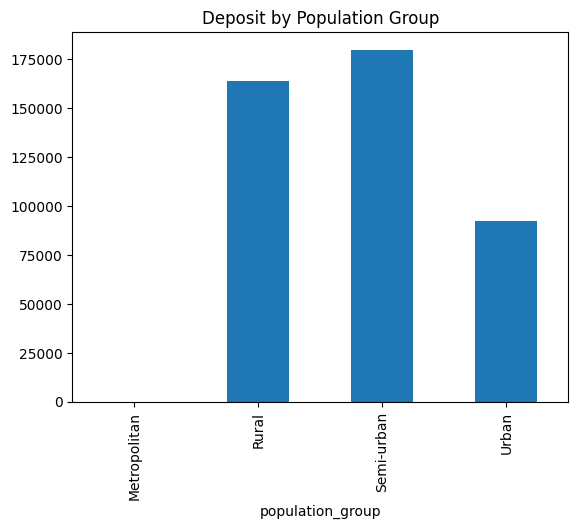

In [129]:
df.groupby("population_group")["total_deposit"].sum().plot(kind="bar")
plt.title("Deposit by Population Group")
plt.show()

#### Insights - Compares deposit contribution across population categories 

## 7. Histogram - Deposit Per Accounnts

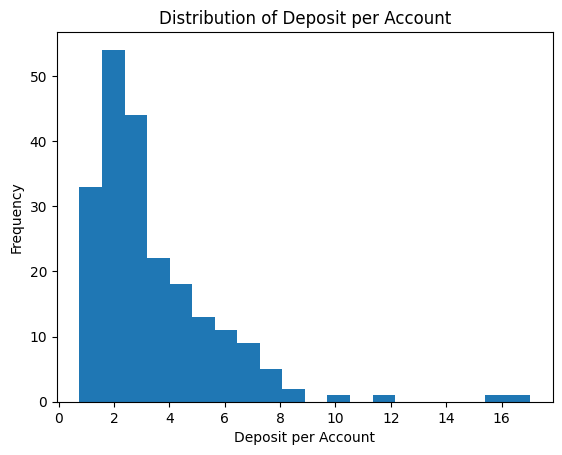

In [130]:
plt.hist(df["deposit_per_account"], bins=20)
plt.title("Distribution of Deposit per Account")
plt.xlabel("Deposit per Account")
plt.ylabel("Frequency")
plt.show()

#### . Insight - Display distribution pattern of customer deposits 

## 8. Area Chart - Accounts Over Years

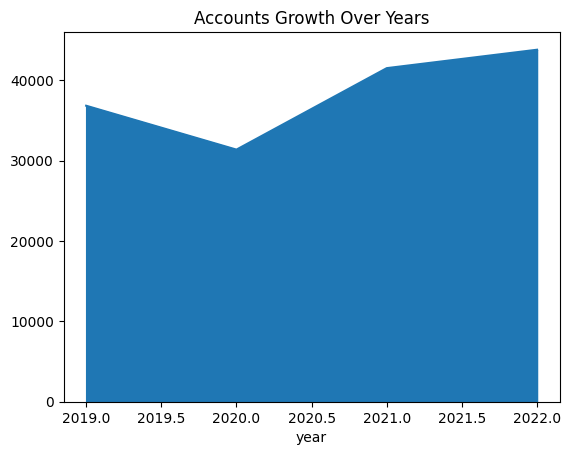

In [131]:
df.groupby("year")["accounts"].sum().plot(kind="area")
plt.title("Accounts Growth Over Years")
plt.show()

#### Insight - Shows cumulative growth pattern

## 9. Correlation Heatmap

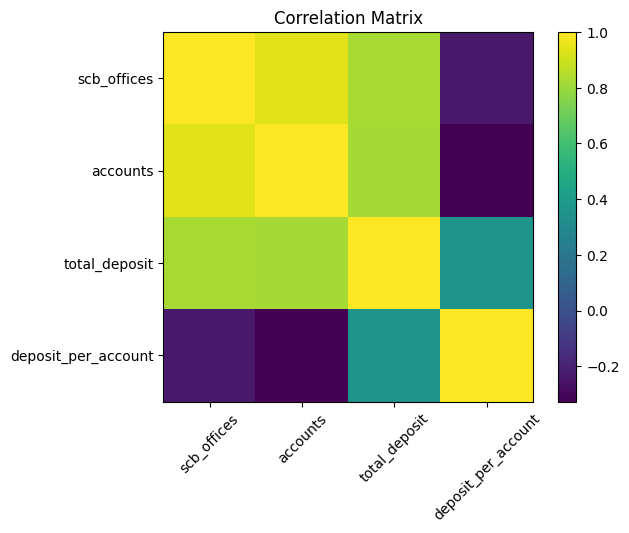

In [132]:
corr = df[["scb_offices","accounts","total_deposit","deposit_per_account"]].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

#### Insight - Shows strength of relationships between numerical variables

## 10. Density Plot - Deposit Per Account

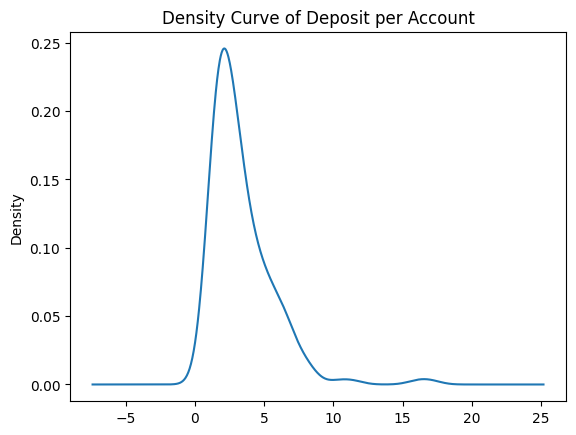

In [134]:
df["deposit_per_account"].plot(kind="density")
plt.title("Density Curve of Deposit per Account")
plt.show()

#### Insight - Smooth curve showing concentration of deposit value

<h2 style="color:skyblue; font-size: 80px; text-decoration: underline;">Conclusion</h2>

This project analyzed banking data focusing on SCB offices, number of accounts, total deposits, 
and deposit per account across different states, regions, and population groups.

From the visualizations and analysis, we observed that total deposits have shown a consistent 
growth trend over the years, indicating expansion in the banking sector. Urban and metropolitan 
areas contribute a higher share of total deposits compared to rural areas, reflecting stronger 
economic activity in those regions.

The analysis also revealed a strong positive relationship between the number of accounts and 
total deposits, suggesting that increased financial inclusion directly impacts deposit growth. 
Similarly, the number of SCB offices shows a positive influence on banking performance, 
highlighting the importance of banking infrastructure.

Overall, this study demonstrates how data analysis and visualization can help understand 
banking growth patterns, regional performance differences, and customer behavior. 
These insights can support better decision-making in financial planning and policy development.